## Interpretability of Linear Time-Variant State Space Sequence Models

State Space Models are a class of sequence models that represent data as the evolution of a hidden state over time:

$x_{t+1} = \bar{A} x_t + \bar{B} u_t, \quad y_t = C_t x_t$


They provide a principled framework for modelling temporal dependencies, widely used in control theory and signal processing.

In modern architectures such as Mamba, these systems become **time-varying and input-dependent**, enabling adaptive and selective processing of sequences.

In [1]:
# Loading in the data and the model

import warnings
warnings.filterwarnings('ignore')
from models.dataloaders.dataloaders import get_sc
from analyse.utils.plots import plot_eigen, plot_frequency_repsponse_one_step, plot_z_transform_one_step, plot_jacobian_dy_dt, plot_variance, plot_real_eigen
from train.train_classifier import MambaClassifierTrainer
from omegaconf import OmegaConf
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

train, val, test = get_sc()
train_iter, val_iter, test_iter = iter(train), iter(val), iter(test)

X, y = next(test_iter)
X, y = X.to('cuda'),y.to('cuda')
X, y = X[:1], y[:1]

config = OmegaConf.load('models/configs/sc/complex_circle.yaml')

model = MambaClassifierTrainer.load_from_checkpoint(
    '/scratch/lhl1g23/mamba/checkpoints/sc/raw/complex/circle/best-v19.ckpt',
    data="sc",
    mamba_config=config.mamba,
    model_config=config.model
).to('cuda')

model.eval()
torch.set_grad_enabled(False)

params_iter = model.classifier.get_params(X[:1], requires_grad=False)
mamba_out, logits = model.classifier(X[:1])
classifier = model.classifier.classifier

X_embed = model.classifier.embed(X)
X_mamba, _ = model.classifier.mamba.layers[0].mixer.in_proj(X_embed).chunk(2, dim=-1)

params = next(params_iter)

A = params['A']
B = params['B']
C = params['C']
D = params['D']
dA = params['dA']
dB = params['dB']
dt = params['dt']
states = params['states']
y_ssm = params['y_ssm']
y_out = params['y_out']

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


In [2]:
from IPython.display import Audio

Audio(X[0].squeeze().cpu().numpy(), rate=16000)

## Eigenvalue Analysis

We analyse the eigenvalues of the state transition matrix $\bar{A}$ to understand the system’s dynamics over time.

Eigenvalues indicate:
- **Stability** (inside the unit circle → stable)
- **Temporal behaviour** (decay, oscillation)

In Mamba, these eigenvalues vary with input, revealing a **time-varying and adaptive system** rather than a fixed linear model.

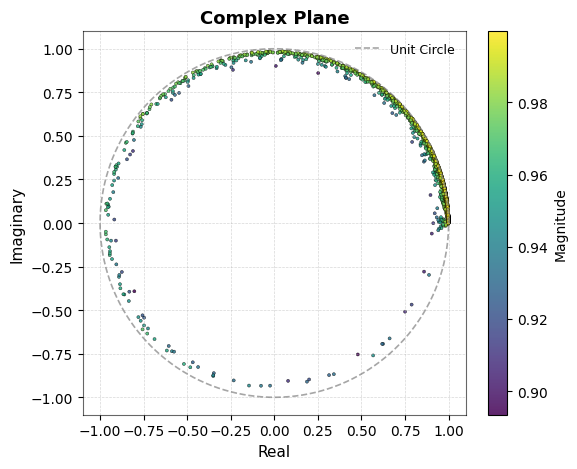

In [3]:
# Eigenvalue plot on imaginary plane

plot_eigen(torch.flatten(dA[0, 0, :, :].cpu()), plt.gca(), s=5)

## Sensitivity Analysis

We study the sensitivity of the eigenvalue variance and the output with respect to the time-step parameter $\Delta$:

$
\frac{\partial y}{\partial \Delta}
$

This Jacobian captures how strongly each time step influences the model’s output.

High sensitivity indicates **important or attended inputs**, showing how Mamba selectively processes sequences over time.

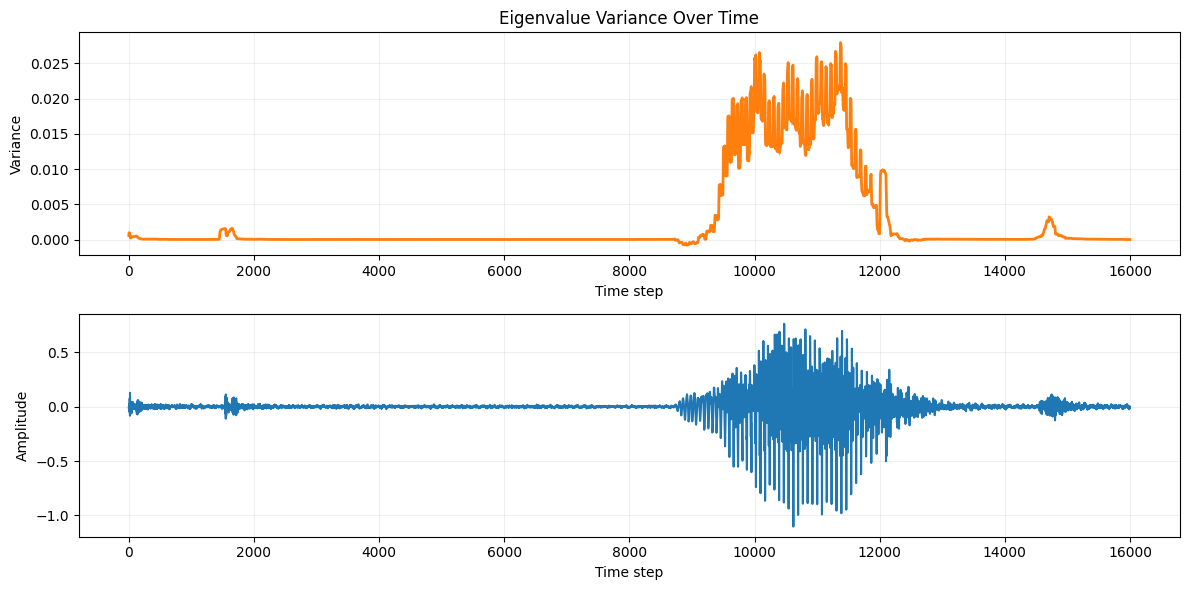

In [4]:
# Plotting the eigenvalue variance

fig, ax = plt.subplots(2,1, figsize=(12,6))
plot_variance(dA, ax[0], 0)
ax[1].plot(X[0,:,0].cpu().numpy())
ax[1].set_xlabel("Time step")
ax[1].set_ylabel("Amplitude")
ax[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

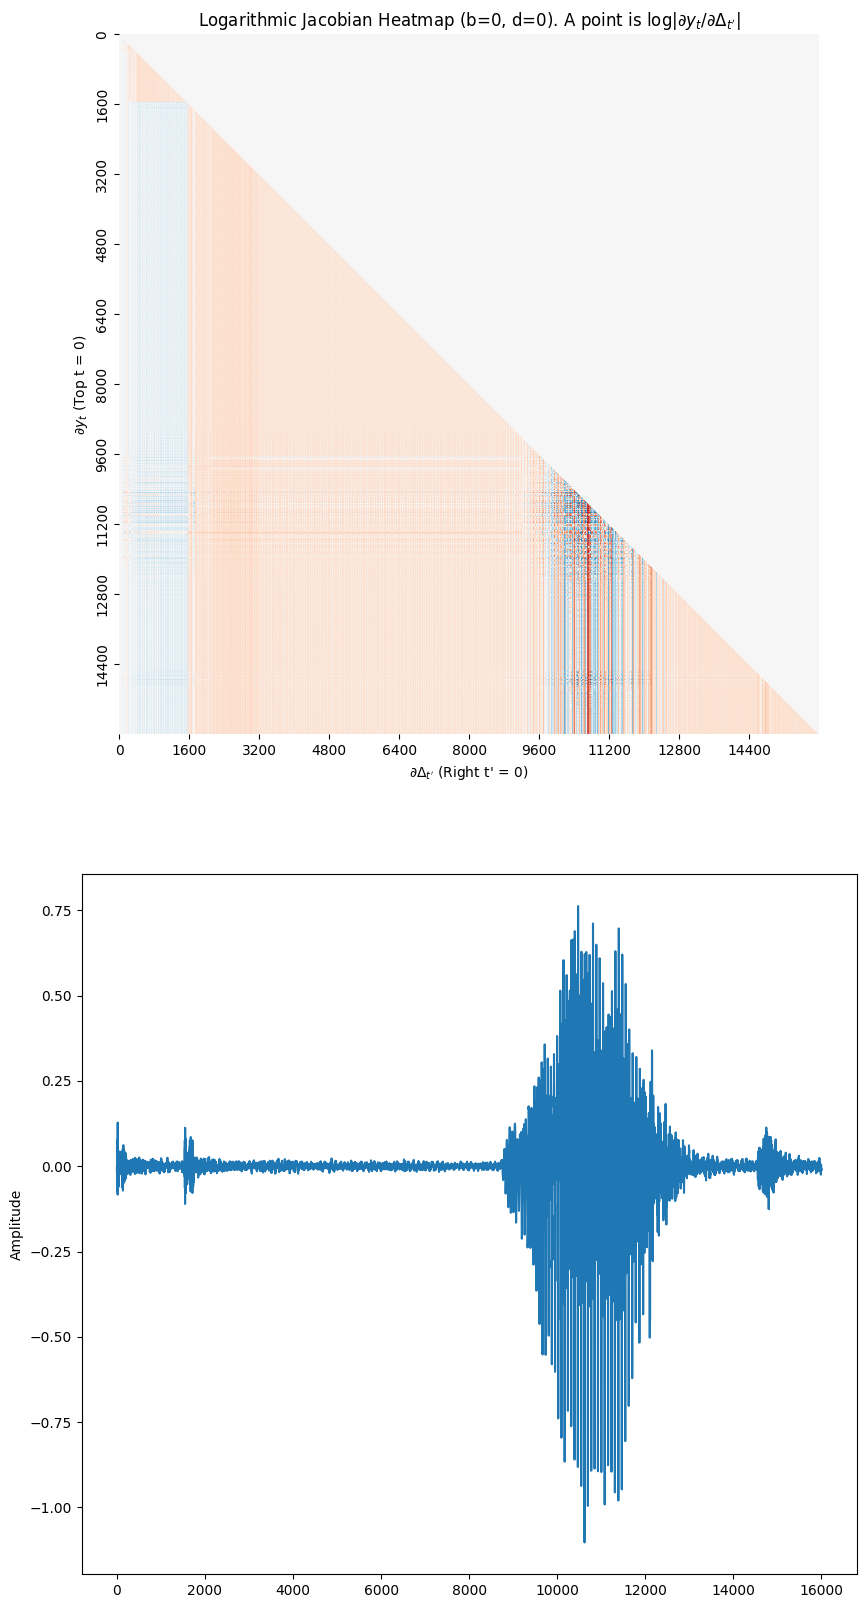

In [5]:
# Jacobian heatmap

fig, ax = plt.subplots(2, 1, figsize=(10, 20))

l = X[0].shape[0]
ax[1].plot(X[0].to('cpu'))
ax[1].set_ylabel("Amplitude")

plot_jacobian_dy_dt(params, X_mamba, 0, 0, ax[0], log=True, cbar=False)

## Spectral Analysis

We interpret the model in the frequency domain using tools such as the Z-transform and frequency response.

This allows us to view Mamba as a **dynamic filter**, where:
- Different inputs produce different frequency responses
- The model adapts how it processes signals over time

This provides a signal processing perspective on its selective behaviour.

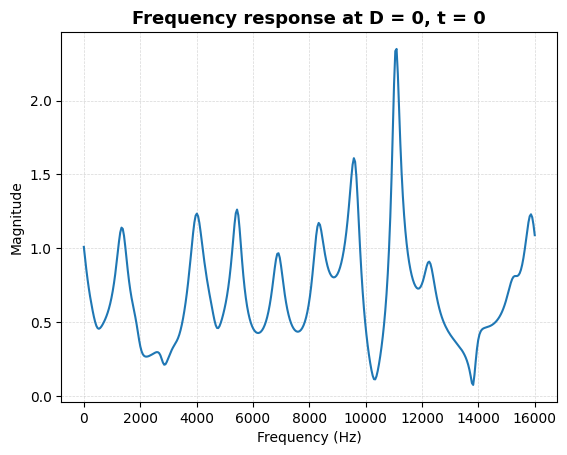

In [6]:
# Frequency response

plot_frequency_repsponse_one_step(dA, dB, C, 0, 0, 0, plt.gca())

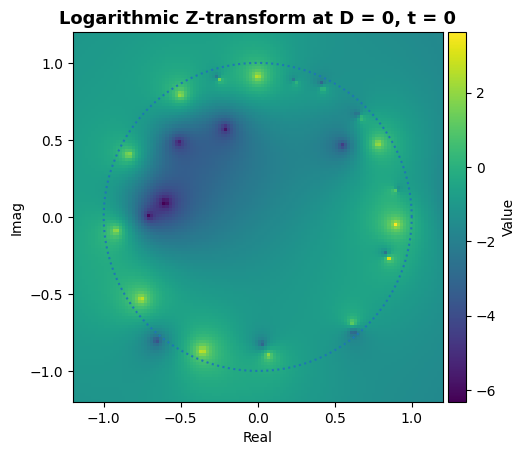

In [7]:
# Z-domain response

plot_z_transform_one_step(dA, dB, C, 0, 0, 0, plt.gca(), log=True)